# ICOS zarr store — variable explorer

Demonstrates reading the zarr v2 store produced by `fluxnet2zarr.py`
and plotting the same key variables shown in `explore_restructured.ipynb`.

| Group path | Time resolution | Key content |
|---|---|---|
| `SE-Svb/` (root) | Half-hourly | Met forcing, NEE, GPP, RECO, LE, H, soil scalars |
| `SE-Svb/meteosens` | Half-hourly | METEOSENS 4-D profile vars `(time, r, h, v)` |
| `SE-Svb/fluxnet_dd` | Daily | Same variables aggregated to daily |
| `SE-Svb/fluxnet_mm` | Monthly | Monthly means |
| `SE-Svb/fluxnet_ww` | Weekly | Weekly means |
| `SE-Svb/fluxnet_yy` | Annual | Annual sums / means |

In [21]:
import pathlib
import json
from contextlib import nullcontext
import numpy as np
import zarr
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

STORE = pathlib.Path("icos-fluxnet.zarr")
SITE  = "SE-Svb"

# ── Data passport proxy toggle ────────────────────────────────────────────────
# Set USE_PROXY = True when run_proxy.py is running.
# Launch proxy:  python run_proxy.py --store-dir . --port 8080
USE_PROXY = True
PROXY_URL = f"http://localhost:8080/icos-fluxnet.zarr"

# Each station group has its own .zmetadata (consolidated by fluxnet2zarr.py).
# zarr v2 supports consolidated=True with our v2-formatted .zmetadata.
# zarr v3's consolidated path looks at v3-only metadata keys ("meta/root/...")
# which our store doesn't have, so on v3 we must force consolidated=False.
_zarr_v2    = int(zarr.__version__.split(".")[0]) < 3
_xr_open_kw = {"consolidated": True} if _zarr_v2 else {"consolidated": False}


def open_group(group: str = "", **kwargs):
    """
    Open a zarr group for data access.

    USE_PROXY=True  → DataPassportDataset (context-manager, mints passport on close)
    USE_PROXY=False → nullcontext-wrapped xr.Dataset (identical interface, no proxy)

    Either way: use as `with open_group("SE-Svb") as ds:` or call .close() manually.
    """
    if USE_PROXY:
        from datapassport_zarr import open_zarr
        return open_zarr(PROXY_URL, group=group, **{**_xr_open_kw, **kwargs})
    ds = xr.open_zarr(str(STORE), group=group or None, **{**_xr_open_kw, **kwargs})
    return nullcontext(ds)


# ── Store metadata ─────────────────────────────────────────────────────────────
# Direct zarr.open_group for structural inspection — no passport needed here.
z = zarr.open_group(str(STORE), mode="r")

print(f"zarr version : {zarr.__version__}")
print(f"Proxy mode   : {'ON  →  ' + PROXY_URL if USE_PROXY else 'OFF (direct file access)'}")
print("Stations  :", sorted(z.group_keys()))
print("Sub-groups:", sorted(z[SITE].group_keys()))
print("Root arrays:", len(list(z[SITE].array_keys())))

prov = json.loads(z[SITE].attrs["_provenance"])
print(f"\n── Provenance for {SITE} ──")
print(f"  Created      : {prov['created']}")
print(f"  Last updated : {prov['last_updated']}")
print(f"  Archive      : {prov['archive']}")
print(f"  Source DOI   : {prov['source_doi']}")
print(f"  Citation     : {prov['citation'][:120]}…")
print(f"  History      :")
for h in prov["history"]:
    print(f"    {h['timestamp']}  {h['action']:8s}  {h['archive']}")

zarr version : 2.18.7
Proxy mode   : ON  →  http://localhost:8080/icos-fluxnet.zarr
Stations  : ['BE-Bra', 'BE-Dor', 'BE-Lon', 'BE-Maa', 'BE-Vie', 'CZ-BK1', 'CZ-Lnz', 'DE-Geb', 'DE-HoH', 'DE-RuS', 'DE-Tha', 'DK-Sor', 'FI-Hyy', 'FI-Sii', 'FI-Sod', 'FR-Bil', 'FR-FBn', 'FR-Fon', 'FR-Gri', 'FR-Hes', 'FR-Lqu', 'FR-Lus', 'FR-Pue', 'GL-ZaF', 'IT-BCi', 'IT-Cp2', 'IT-MBo', 'IT-Ren', 'IT-SR2', 'NL-Loo', 'NO-Hur', 'SE-Htm', 'SE-Nor', 'SE-Svb', 'UK-AMo']
Sub-groups: ['fluxnet_dd', 'fluxnet_mm', 'fluxnet_ww', 'fluxnet_yy', 'meteosens']
Root arrays: 822

── Provenance for SE-Svb ──
  Created      : 2026-04-15T08:06:07Z
  Last updated : 2026-04-15T08:06:07Z
  Archive      : ICOSETC_SE-Svb_ARCHIVE_INTERIM_L2.zip
  Source DOI   : https://hdl.handle.net/11676/ZtajDQjqJOCrTLKYK3BbJhHK
  Citation     : Peichl, M., Nilsson, M., Larmanou, E., Smith, P., Marklund, P., De Simon, G., Lofvenius, P., Dignam, R., Holst, J., Mold…
  History      :
    2026-04-15T08:06:07Z  create    ICOSETC_SE-Svb_ARCHIVE_INTERIM_

## 0 · Dataset structure

Open each group with xarray and inspect dimensions, coordinates, and variable counts.

In [23]:
# Open all groups via open_group().
# Context managers are entered now; call _close_all() in the final cell to mint passports.
_ctx_hh        = open_group(f"{SITE}")
_ctx_dd        = open_group(f"{SITE}/fluxnet_dd")
_ctx_mm        = open_group(f"{SITE}/fluxnet_mm")
_ctx_ww        = open_group(f"{SITE}/fluxnet_ww")
_ctx_yy        = open_group(f"{SITE}/fluxnet_yy")
_ctx_meteosens = open_group(f"{SITE}/meteosens") \
                 if "meteosens" in z[SITE].group_keys() else None

ds_hh        = _ctx_hh.__enter__()
ds_dd        = _ctx_dd.__enter__()
ds_mm        = _ctx_mm.__enter__()
ds_ww        = _ctx_ww.__enter__()
ds_yy        = _ctx_yy.__enter__()
ds_meteosens = _ctx_meteosens.__enter__() if _ctx_meteosens is not None else None


def _close_all():
    """Close all open group contexts, minting passports when USE_PROXY=True."""
    for ctx in [_ctx_hh, _ctx_dd, _ctx_mm, _ctx_ww, _ctx_yy]:
        ctx.__exit__(None, None, None)
    if _ctx_meteosens is not None:
        _ctx_meteosens.__exit__(None, None, None)


for label, ds in [("root (HH)", ds_hh), ("fluxnet_dd", ds_dd),
                  ("fluxnet_mm", ds_mm), ("fluxnet_ww", ds_ww), ("fluxnet_yy", ds_yy)]:
    n_vars = len(ds.data_vars)
    dims   = dict(ds.sizes)
    print(f"  {label:<14}  {n_vars:4d} vars   dims={dims}")
if ds_meteosens is not None:
    print(f"  {'meteosens':<14}  {len(ds_meteosens.data_vars):4d} vars   dims={dict(ds_meteosens.sizes)}")

KeyError: '.zmetadata'

In [24]:
# Inspect the 3-D NEE variable (time × ustar_threshold × nee_variant)
print(ds_hh["NEE"])
print()
print("ustar_threshold labels:", ds_hh["NEE"].ustar_threshold.values)
print("nee_variant labels    :", ds_hh["NEE"].nee_variant.values)

<xarray.DataArray 'NEE' (time: 122736, ustar_threshold: 2, nee_variant: 11)> Size: 11MB
[2700192 values with dtype=float32]
Coordinates:
  * time             (time) datetime64[ns] 982kB 2019-01-01 ... 2025-12-31T23...
  * ustar_threshold  (ustar_threshold) <U3 24B 'CUT' 'VUT'
  * nee_variant      (nee_variant) <U7 308B 'REF' 'USTAR50' ... 'p84' 'p95'
Attributes:
    comment:    ustar_threshold: CUT = constant, VUT = variable. nee_variant:...
    long_name:  Net Ecosystem Exchange
    units:      umol m-2 s-1

ustar_threshold labels: ['CUT' 'VUT']
nee_variant labels    : ['REF' 'USTAR50' 'MEAN' 'SE' 'p05' 'p16' 'p25' 'p50' 'p75' 'p84' 'p95']


## 1 · Half-hourly meteorology (root group)

Air temperature and incoming shortwave radiation using xarray label-based indexing.

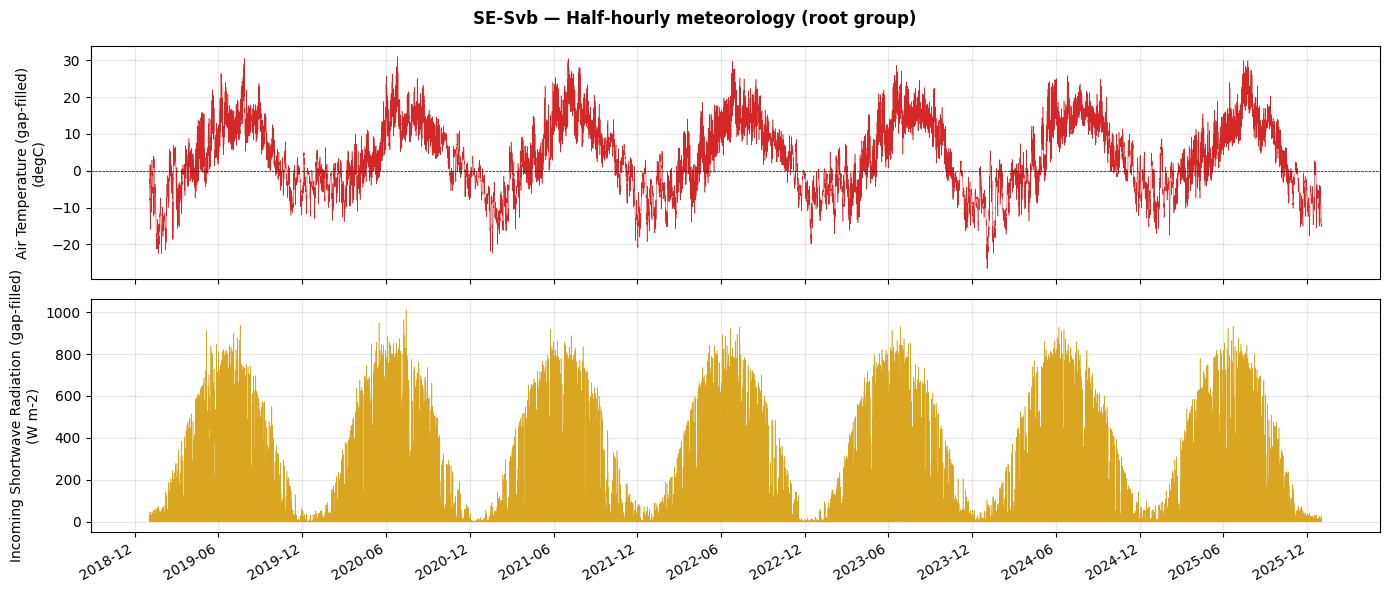

In [8]:
def _ylabel(da):
    ln = da.attrs.get("long_name", da.name or "")
    u  = da.attrs.get("units", "")
    return f"{ln}\n({u})" if u else ln

site_id = ds_hh.attrs.get("site_id", SITE)

da_ta    = ds_hh["TA_F"]
da_sw_in = ds_hh["SW_IN_F"]
ta    = da_ta.values.astype(float)
sw_in = da_sw_in.values.astype(float)
t_hh  = ds_hh["time"].values

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f"{site_id} — Half-hourly meteorology (root group)", fontweight="bold")

axes[0].plot(t_hh, ta, lw=0.4, color="tab:red")
axes[0].set_ylabel(_ylabel(da_ta))
axes[0].axhline(0, color="k", lw=0.5, ls="--")

axes[1].plot(t_hh, sw_in, lw=0.4, color="goldenrod")
axes[1].set_ylabel(_ylabel(da_sw_in))

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.grid(alpha=0.3)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## 2 · Daily carbon fluxes (`fluxnet_dd`)

**Top** — NEE with joint uncertainty envelope (VUT threshold, REF variant), using xarray `.sel()`.  
**Bottom** — GPP and RECO from both partitioning methods (NT = night-time, DT = day-time).

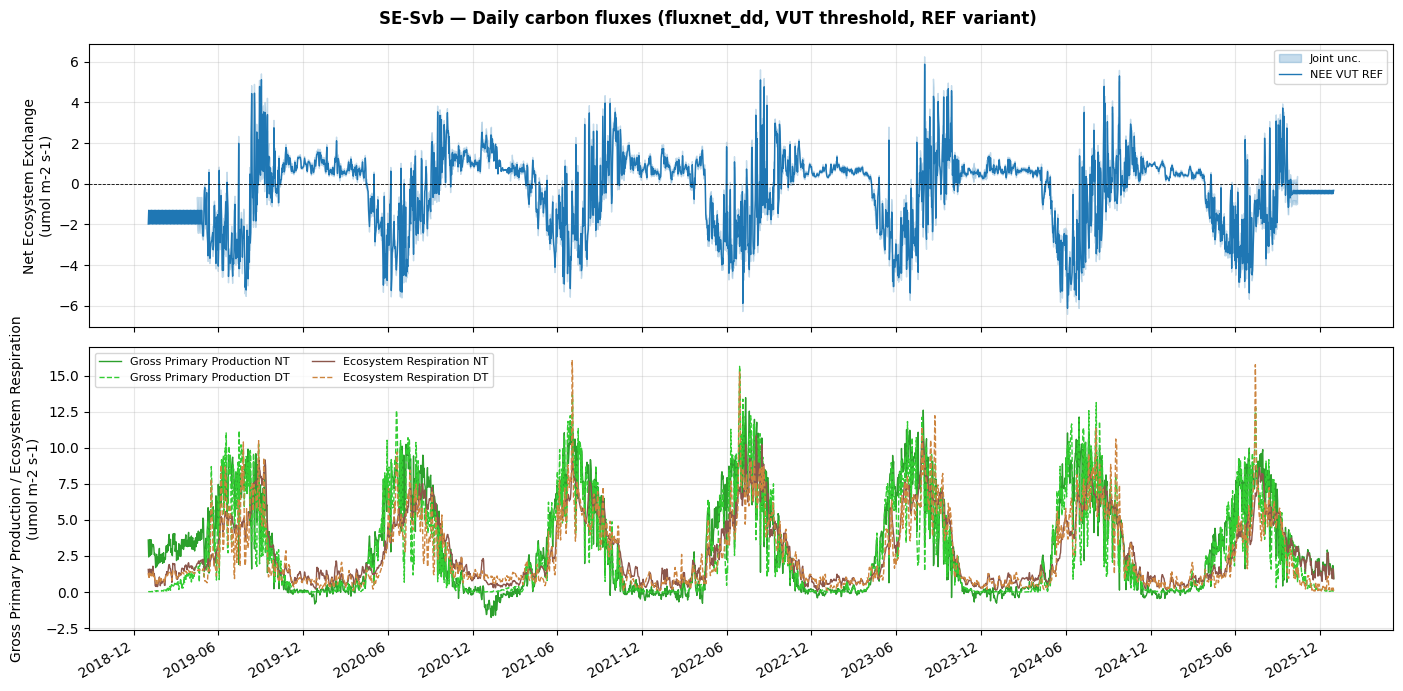

In [9]:
t_dd = ds_dd["time"].values

nee     = ds_dd["NEE"].sel(ustar_threshold="VUT", nee_variant="REF").values.astype(float)
nee_unc = ds_dd["NEE_JOINTUNC"].sel(ustar_threshold="VUT", nee_variant="REF").values.astype(float)
gpp_nt  = ds_dd["GPP"].sel(ustar_threshold="VUT", partition_method="NT", nee_variant="REF").values.astype(float)
gpp_dt  = ds_dd["GPP"].sel(ustar_threshold="VUT", partition_method="DT", nee_variant="REF").values.astype(float)
reco_nt = ds_dd["RECO"].sel(ustar_threshold="VUT", partition_method="NT", nee_variant="REF").values.astype(float)
reco_dt = ds_dd["RECO"].sel(ustar_threshold="VUT", partition_method="DT", nee_variant="REF").values.astype(float)

nee_ln    = ds_dd["NEE"].attrs.get("long_name", "NEE")
gpp_ln    = ds_dd["GPP"].attrs.get("long_name", "GPP")
reco_ln   = ds_dd["RECO"].attrs.get("long_name", "RECO")
nee_units = ds_dd["NEE"].attrs.get("units", "")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(f"{site_id} — Daily carbon fluxes (fluxnet_dd, VUT threshold, REF variant)",
             fontweight="bold")

ax = axes[0]
ax.fill_between(t_dd, nee - nee_unc, nee + nee_unc, alpha=0.25, color="tab:blue", label="Joint unc.")
ax.plot(t_dd, nee, lw=1, color="tab:blue", label="NEE VUT REF")
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_ylabel(f"{nee_ln}\n({nee_units})" if nee_units else nee_ln)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(t_dd, gpp_nt,  lw=1, color="tab:green", label=f"{gpp_ln} NT")
ax.plot(t_dd, gpp_dt,  lw=1, color="limegreen",  label=f"{gpp_ln} DT", ls="--")
ax.plot(t_dd, reco_nt, lw=1, color="tab:brown",  label=f"{reco_ln} NT")
ax.plot(t_dd, reco_dt, lw=1, color="peru",        label=f"{reco_ln} DT", ls="--")
ax.set_ylabel(f"{gpp_ln} / {reco_ln}\n({nee_units})" if nee_units else f"{gpp_ln} / {reco_ln}")
ax.legend(fontsize=8, ncol=2)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.grid(alpha=0.3)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## 3 · Monthly energy balance & soil profiles (`fluxnet_mm`)

**Top** — Latent heat (LE) and sensible heat (H) at the median energy-balance correction (p50).  
**Bottom** — Soil temperature and soil water content profiles across all measured layers.

/tmp/ipykernel_13332/3416341695.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_ts  = plt.cm.get_cmap("YlOrRd", max(n_ts,  2))
/tmp/ipykernel_13332/3416341695.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_swc = plt.cm.get_cmap("Blues",  max(n_swc, 3))


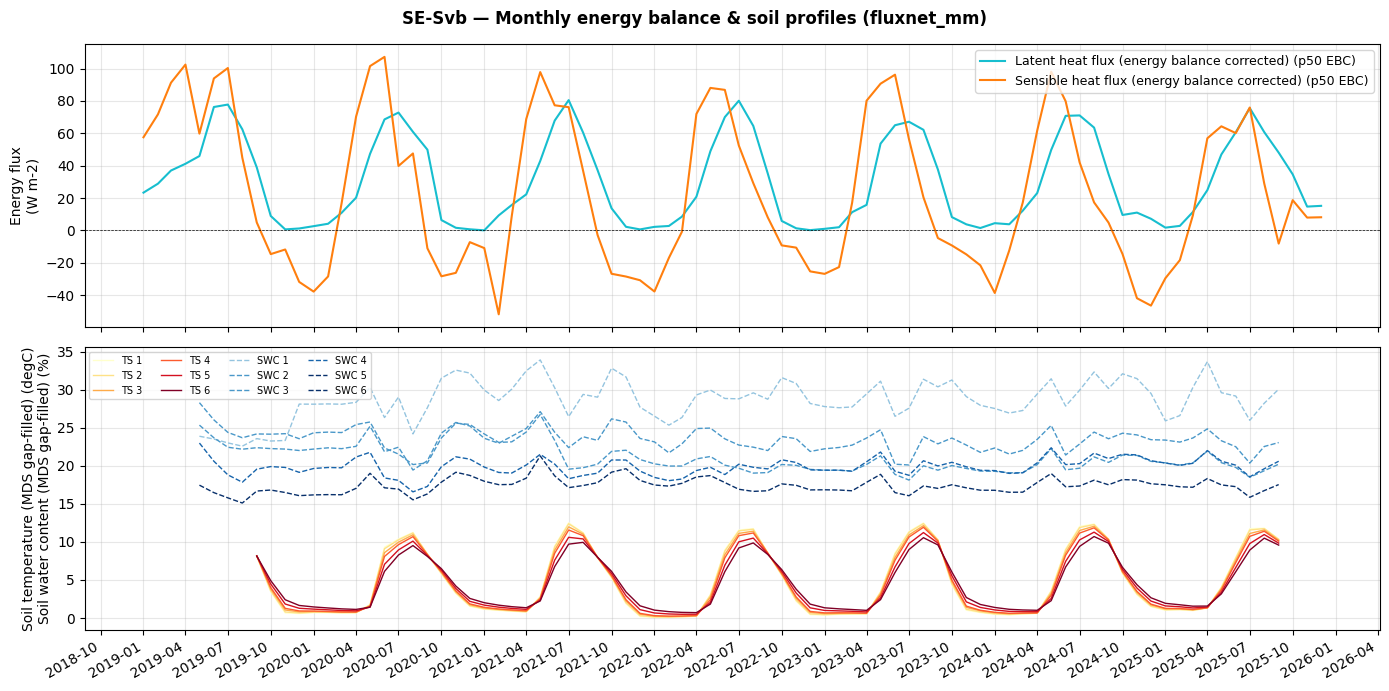

In [10]:
t_mm = ds_mm["time"].values

da_le  = ds_mm["LE_CORR"]
da_h   = ds_mm["H_CORR"]
da_ts  = ds_mm["TS"]
da_swc = ds_mm["SWC"]

le = da_le.sel(corr_pct="p50").values.astype(float)
h  = da_h.sel(corr_pct="p50").values.astype(float)

ts_all      = da_ts.values.astype(float)
swc_all     = da_swc.values.astype(float)
soil_labels = da_ts.soil_layer.values

le_ln   = da_le.attrs.get("long_name", "Latent heat flux")
h_ln    = da_h.attrs.get("long_name", "Sensible heat flux")
e_units = da_le.attrs.get("units", "W m-2")
ts_ln   = da_ts.attrs.get("long_name", "Soil temperature")
ts_u    = da_ts.attrs.get("units", "degC")
swc_ln  = da_swc.attrs.get("long_name", "SWC")
swc_u   = da_swc.attrs.get("units", "%")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(f"{site_id} — Monthly energy balance & soil profiles (fluxnet_mm)", fontweight="bold")

ax = axes[0]
ax.plot(t_mm, le, lw=1.5, color="tab:cyan",   label=f"{le_ln} (p50 EBC)")
ax.plot(t_mm, h,  lw=1.5, color="tab:orange", label=f"{h_ln} (p50 EBC)")
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_ylabel(f"Energy flux\n({e_units})")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
n_ts  = ts_all.shape[1]
n_swc = swc_all.shape[1]
cmap_ts  = plt.cm.get_cmap("YlOrRd", max(n_ts,  2))
cmap_swc = plt.cm.get_cmap("Blues",  max(n_swc, 3))
for i in range(n_ts):
    ax.plot(t_mm, ts_all[:, i],  lw=1, color=cmap_ts(i / max(n_ts - 1, 1)),
            label=f"TS {soil_labels[i]}")
for i in range(n_swc):
    ax.plot(t_mm, swc_all[:, i], lw=1, color=cmap_swc(0.4 + 0.6 * i / max(n_swc - 1, 1)),
            ls="--", label=f"SWC {soil_labels[i]}")
ax.set_ylabel(f"{ts_ln} ({ts_u})\n{swc_ln} ({swc_u})")
ax.legend(fontsize=7, ncol=4)
ax.grid(alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## 4 · Annual carbon budget (`fluxnet_yy`)

Bar chart of annual NEE, GPP, and RECO (VUT threshold, REF variant, NT partitioning).  
Negative NEE = net carbon uptake (sink); positive = source.

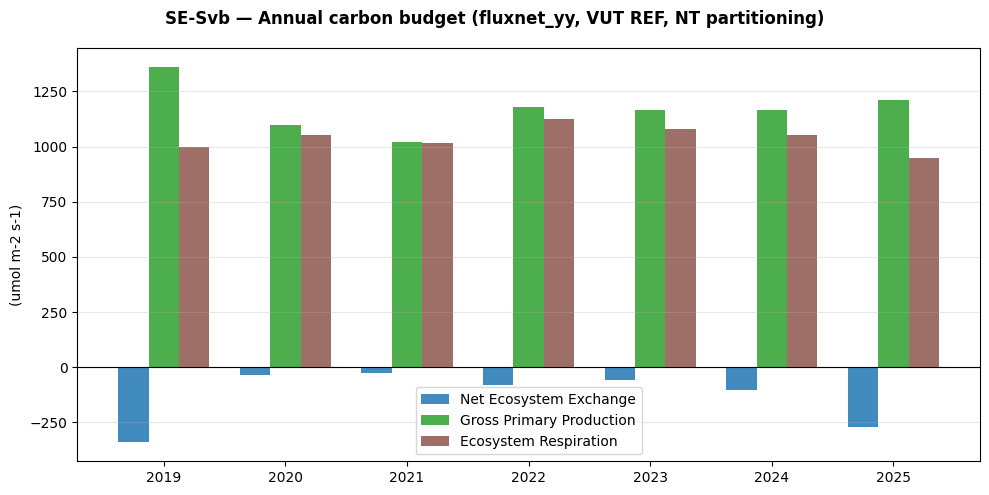

In [11]:
t_yy  = ds_yy["time"].values
years = t_yy.astype("datetime64[Y]").astype(int) + 1970

da_nee  = ds_yy["NEE"]
da_gpp  = ds_yy["GPP"]
da_reco = ds_yy["RECO"]

nee_y  = da_nee.sel(ustar_threshold="VUT", nee_variant="REF").values.astype(float)
gpp_y  = da_gpp.sel(ustar_threshold="VUT", partition_method="NT", nee_variant="REF").values.astype(float)
reco_y = da_reco.sel(ustar_threshold="VUT", partition_method="NT", nee_variant="REF").values.astype(float)

nee_ln  = da_nee.attrs.get("long_name",  "NEE")
gpp_ln  = da_gpp.attrs.get("long_name",  "GPP")
reco_ln = da_reco.attrs.get("long_name", "RECO")
units   = da_nee.attrs.get("units", "")

x = np.arange(len(years))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(f"{site_id} — Annual carbon budget (fluxnet_yy, VUT REF, NT partitioning)",
             fontweight="bold")

ax.bar(x - w, nee_y,  w, label=nee_ln,  color="tab:blue",  alpha=0.85)
ax.bar(x,     gpp_y,  w, label=gpp_ln,  color="tab:green", alpha=0.85)
ax.bar(x + w, reco_y, w, label=reco_ln, color="tab:brown", alpha=0.85)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel(f"({units})" if units else "")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()


## 5 · METEOSENS 4-D profile variables (`meteosens` sub-group)

METEOSENS profile variables (e.g. `TA`, `LW_IN`, `SWC`) live in the `meteosens` sub-group
with dimensions `(time, r, h, v)` — repeat/replicate, height, vertical position.  
Plot monthly means for each (r, h, v) combination that has valid data.

TA shape : (122736, 5, 16, 2)
TA dims  : ('time', 'TA_r', 'TA_h', 'TA_v')
  Plotted 22 non-empty (r, h, v) combination(s)


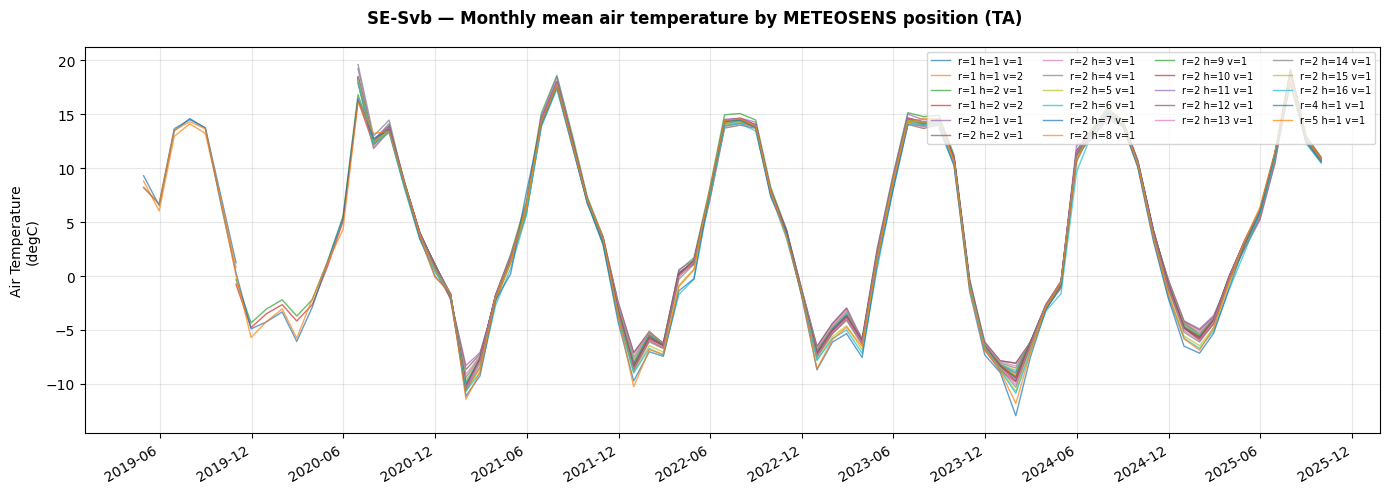

In [12]:
if ds_meteosens is None:
    print("No meteosens sub-group found in this store.")
elif "TA" not in ds_meteosens:
    print("TA not found in meteosens group. Available vars:", list(ds_meteosens.data_vars))
else:
    ta4d = ds_meteosens["TA"]   # DataArray (time, TA_r, TA_h, TA_v)
    print("TA shape :", ta4d.shape)
    print("TA dims  :", ta4d.dims)

    # Resample to monthly means, then plot one line per (r,h,v) combo with valid data
    ta_monthly = ta4d.resample(time="ME").mean()

    r_vals = ta4d.coords[ta4d.dims[1]].values
    h_vals = ta4d.coords[ta4d.dims[2]].values
    v_vals = ta4d.coords[ta4d.dims[3]].values
    t_mo   = ta_monthly.time.values

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f"{site_id} — Monthly mean air temperature by METEOSENS position (TA)",
                 fontweight="bold")

    n_plotted = 0
    for ri, r in enumerate(r_vals):
        for hi, h in enumerate(h_vals):
            for vi, v in enumerate(v_vals):
                col = ta_monthly.isel(**{ta4d.dims[1]: ri,
                                         ta4d.dims[2]: hi,
                                         ta4d.dims[3]: vi}).values.astype(float)
                if np.all(np.isnan(col)):
                    continue
                ax.plot(t_mo, col, lw=1, alpha=0.7, label=f"r={r} h={h} v={v}")
                n_plotted += 1

    print(f"  Plotted {n_plotted} non-empty (r, h, v) combination(s)")
    ta_units = ta4d.attrs.get("units", "")
    ta_ln    = ta4d.attrs.get("long_name", "Air temperature")
    ax.set_ylabel(f"{ta_ln}\n({ta_units})" if ta_units else ta_ln)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.legend(fontsize=7, ncol=4, loc="upper right")
    ax.grid(alpha=0.3)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## 6 · Store summary — all variables and their shapes

In [13]:
groups = [("root (HH)", ds_hh), ("fluxnet_dd", ds_dd),
          ("fluxnet_mm", ds_mm), ("fluxnet_ww", ds_ww), ("fluxnet_yy", ds_yy)]
if ds_meteosens is not None:
    groups.append(("meteosens", ds_meteosens))

for label, ds in groups:
    nd = sum(1 for v in ds.data_vars if len(ds[v].dims) > 1)
    n1 = sum(1 for v in ds.data_vars if len(ds[v].dims) == 1)
    print(f"\n{'─'*60}")
    print(f"  {label}   ({nd} multi-dim, {n1} 1-D)")
    print(f"{'─'*60}")
    # multi-dim first, then 1-D, sorted
    for vname in sorted(ds.data_vars, key=lambda v: (-len(ds[v].dims), v)):
        da = ds[vname]
        units = da.attrs.get("units", "")
        print(f"  {vname:<30s}  {str(da.dims):<55s}  {str(da.shape):<25s}  {units}")


────────────────────────────────────────────────────────────
  root (HH)   (450 multi-dim, 248 1-D)
────────────────────────────────────────────────────────────
  GPP                             ('time', 'partition_method', 'ustar_threshold', 'nee_variant')  (122736, 2, 2, 11)         umol m-2 s-1
  GPP_QC                          ('time', 'partition_method', 'ustar_threshold', 'nee_variant')  (122736, 2, 2, 11)         1
  RECO                            ('time', 'partition_method', 'ustar_threshold', 'nee_variant')  (122736, 2, 2, 11)         umol m-2 s-1
  RECO_QC                         ('time', 'partition_method', 'ustar_threshold', 'nee_variant')  (122736, 2, 2, 11)         1
  NEE                             ('time', 'ustar_threshold', 'nee_variant')               (122736, 2, 11)            umol m-2 s-1
  NEE_JOINTUNC                    ('time', 'ustar_threshold', 'nee_variant')               (122736, 2, 11)            umol m-2 s-1
  NEE_QC                          ('time', 'us

## 7 · Data passport

When `USE_PROXY = True`, run the cell below to close all proxy sessions and mint a
data passport for each group accessed above.  Each passport records the exact chunks
delivered, per-variable SHA-256 checksums, and the xarray query chain (`.sel()`/`.isel()` calls).

The Handle PID printed below is the citable identifier for this specific data delivery.

In [14]:
# Close all proxy sessions and mint passports.
# Safe to run even when USE_PROXY=False — it's a no-op in that case.
_close_all()

if not USE_PROXY:
    print("USE_PROXY=False — no passport minted.")
    print("Set USE_PROXY=True and re-run the notebook with the proxy running to get a passport.")

[datapassport_zarr] Session closed (2109 chunks) — Handle/CP not configured, no PID minted.
[datapassport_zarr] Warning: session closed with 0 chunks — no data was read from the store. The passport covers only what was actually delivered; lazy arrays that were never computed are not included.
[datapassport_zarr] Warning: session closed with 0 chunks — no data was read from the store. The passport covers only what was actually delivered; lazy arrays that were never computed are not included.
[datapassport_zarr] Warning: session closed with 0 chunks — no data was read from the store. The passport covers only what was actually delivered; lazy arrays that were never computed are not included.
[datapassport_zarr] Warning: session closed with 0 chunks — no data was read from the store. The passport covers only what was actually delivered; lazy arrays that were never computed are not included.
[datapassport_zarr] Warning: session closed with 0 chunks — no data was read from the store. The pas